In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/fraud_detection_paysim_dataset.csv")

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (6362620, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [ ]:
df["is_transfer_or_cashout"] = (
    df["type"].isin(["TRANSFER","CASH_OUT"])
).astype(int)
#only these two types of transactions can be fraudulent, so we create a new feature to capture this information.

In [3]:
#there are some inconsistencies/ error in balance after the transaction
df["orig_balance_error"] = (
    df["oldbalanceOrg"] - df["newbalanceOrig"] - df["amount"]
)

df["dest_balance_error"] = (
    df["oldbalanceDest"] + df["amount"] - df["newbalanceDest"]
)

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_feature_relationship(df, feature, target="isFraud", sample=100000):

    data = df.sample(min(sample, len(df)))

    fig, axes = plt.subplots(1, 2, figsize=(14,5))

    # Distribution
    sns.kdeplot(data=data, x=feature, hue=target, ax=axes[0])
    axes[0].set_title(f"{feature} distribution by fraud")

    # Fraud rate by bins
    data["bin"] = pd.qcut(data[feature], q=10, duplicates="drop")

    fraud_rate = data.groupby("bin")[target].mean()

    fraud_rate.plot(kind="bar", ax=axes[1])
    axes[1].set_title(f"Fraud rate by {feature} bins")

    plt.tight_layout()
    plt.show()

/var/folders/vt/534j8p4n44x12n92yxnztyy00000gn/T/ipykernel_19714/3365833572.py:11: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=data, x=feature, hue=target, ax=axes[0])
/var/folders/vt/534j8p4n44x12n92yxnztyy00000gn/T/ipykernel_19714/3365833572.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fraud_rate = data.groupby("bin")[target].mean()


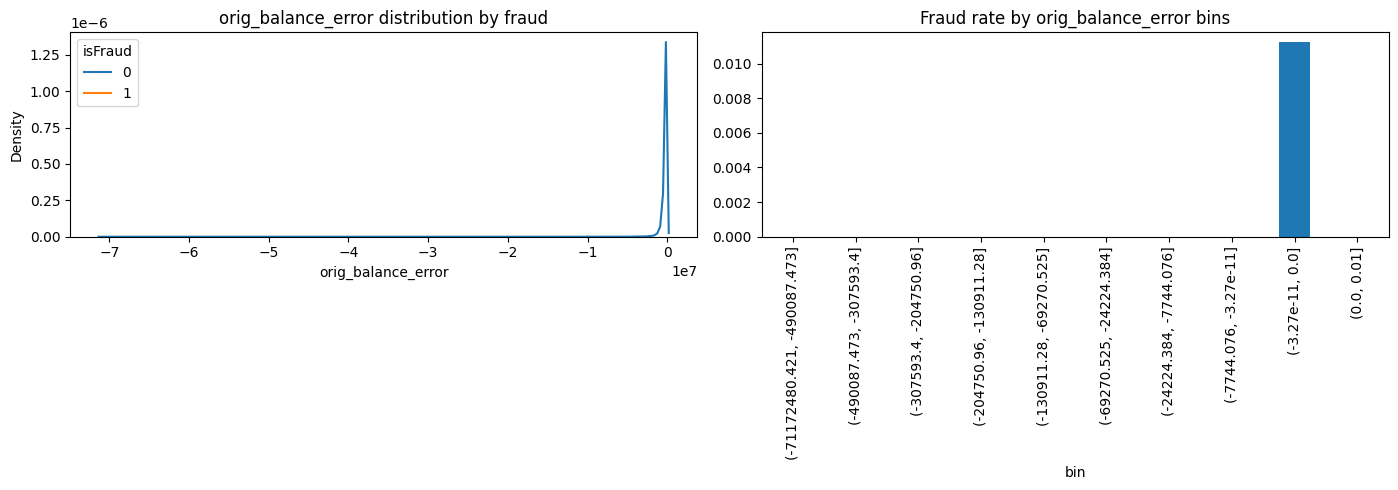

In [5]:
plot_feature_relationship(df, "orig_balance_error")

An important feature can be if entire amount or a large ratio of balance is being transfered.
Or the destination balance is zero/ relatively new account

In [7]:
df["is_full_transfer"] = (
    df["amount"] == df["oldbalanceOrg"]
).astype(int)

df.groupby("is_full_transfer")["isFraud"].mean()

is_full_transfer
0    0.000028
1    1.000000
Name: isFraud, dtype: float64

In [8]:
df["dest_balance_zero"] = (
    (df["oldbalanceDest"] == 0) &
    (df["newbalanceDest"] == 0)
).astype(int)

df.groupby("dest_balance_zero")["isFraud"].mean()

dest_balance_zero
0    0.001023
1    0.001759
Name: isFraud, dtype: float64

Full transfer seems to be a strong indicator of fraud, while zero balance at destination is not as strong. dropping zero balance at destination

In [10]:
df = df.drop(columns=["dest_balance_zero"])

In [11]:
df["amount_balance_ratio"] = (
    df["amount"] / (df["oldbalanceOrg"] + 1)
)

In [12]:
df_model = df.drop(columns=["nameOrig","nameDest"])
df_model = pd.get_dummies(
    df_model,
    columns=["type"],
    drop_first=True
)

In [15]:
df_model.to_csv("../data/processed_fraud_dataset.csv", index=False)